# Evaluate Paper Assessment Prompt

In [1]:
import pandas as pd
import sys
sys.path.append("../")
from dotenv import load_dotenv
load_dotenv()

from src.llm_utils import LLM_wrapper, PaperAssessment
from src.llm_utils import PAPER_ASSESSMENT_PROMPT as paper_assessment_prompt

In [2]:
MODEL_NAME = "gpt-5.2-2025-12-11"
CONTEXT_WINDOW = 395000 # gpt 5.2's context window is 400k tokens

In [3]:
llm_wrapper = LLM_wrapper(
    model_name=MODEL_NAME,
    system_prompt=paper_assessment_prompt,
    output_format_class=PaperAssessment
)

In [4]:
df_pred = llm_wrapper.assess_dataframe(
    input_file_path="../data/02_paper_assessment/gt_paper_assessment.csv",
    text_column="full_text",
    output_dir="../data/02_paper_assessment/"
)

Loading checkpoint from ../data/02_paper_assessment/checkpoints/20260125_1600_gpt-5.2-2025-12-11.checkpoint.csv
Total rows: 500, Already processed: 500, Remaining (after filter): 0


0it [00:00, ?it/s]

Processing complete. Final results saved.


In [3]:
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Read dataset in case no API is available to reproduce the results.
# Here include code to load the df_pred so then the next chunks are reproducible.


In [4]:
# Convert to booleans
df_pred["is_match"] = (
    df_pred["is_match"].astype(str).str.strip().str.lower().map({"true": True, "false": False})
)

if "Yes" in df_pred["gt_in_scope"].values or "No" in df_pred["gt_in_scope"].values:
    df_pred["gt_in_scope"] = (
        df_pred["gt_in_scope"].astype(str).str.strip().str.lower().map({"yes": True, "no": False})
    )

df_pred = df_pred.dropna(subset=["is_match", "gt_in_scope"])

# --- Compute confusion matrix ---
cm = confusion_matrix(df_pred["gt_in_scope"], df_pred["is_match"])
labels = ["Out of scope", "In scope"]

# --- Plot heatmap ---
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    square=True,
)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.title("Confusion Matrix – LLM Paper Assessment vs Ground Truth", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# --- Optional metrics ---
print(classification_report(df_pred["gt_in_scope"], df_pred["is_match"], target_names=labels))

NameError: name 'df_pred' is not defined

Subset size (in-scope only): 393


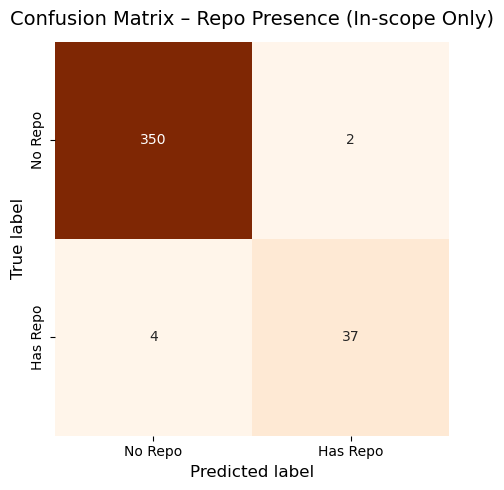

Classification Report:
              precision    recall  f1-score   support

     No Repo       0.99      0.99      0.99       352
    Has Repo       0.95      0.90      0.93        41

    accuracy                           0.98       393
   macro avg       0.97      0.95      0.96       393
weighted avg       0.98      0.98      0.98       393

Cohen’s κ: 0.917


In [7]:
# --- Normalize string columns ---
df_pred["gt_repo_url"] = df_pred["gt_repo_url"].astype(str).str.strip().str.replace("Appendix", "appendix", regex=False).replace({"nan": ""})
df_pred["repo_url"] = df_pred["repo_url"].astype(str).str.strip().str.replace("Appendix", "appendix", regex=False).replace({"nan": ""})

# --- Create binary indicators ---
df_pred["has_repo_gt"] = df_pred["repo_url"].apply(lambda x: bool(x))
df_pred["has_repo_pred"] = df_pred["gt_repo_url"].apply(lambda x: bool(x))

# --- Exact match indicator (for analysis) ---
df_pred["repo_match_exact"] = df_pred.apply(
    lambda r: r["gt_repo_url"] == r["repo_url"] if r["has_repo_gt"] and r["has_repo_pred"] else False,
    axis=1
)

# --- Filter to in-scope only ---
subset = df_pred[df_pred["is_match"] == True].copy()
print(f"Subset size (in-scope only): {len(subset)}")

# --- Compute confusion matrix for repo presence ---
cm = confusion_matrix(subset["has_repo_gt"], subset["has_repo_pred"])
labels = ["No Repo", "Has Repo"]

# --- Plot confusion matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    square=True,
)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.title("Confusion Matrix – Repo Presence (In-scope Only)", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# --- Compute metrics ---
print("Classification Report:")
print(classification_report(subset["has_repo_gt"], subset["has_repo_pred"], target_names=labels))
print(f"Cohen’s κ: {cohen_kappa_score(subset['has_repo_gt'], subset['has_repo_pred']):.3f}")

# --- (Optional) Report URL-level exact matches ---
exact_matches = subset["repo_match_exact"].sum()

In [8]:
# subset = df_pred[df_pred["is_match"] == True].copy()

# Make sure these are defined correctly:
has_gt = subset["gt_repo_url"].astype(str).str.strip().ne("")
has_pred = subset["repo_url"].astype(str).str.strip().ne("")

gt = subset["gt_repo_url"].astype(str).str.strip()
pred = subset["repo_url"].astype(str).str.strip()

exact = (gt == pred) & has_gt & has_pred

den = int(has_gt.sum())
num = int(exact.sum())
ratio = (num / den) if den else float("nan")

print(f"Exact URL retrieval (among GT repos): {num}/{den} ({ratio:.1%})")

Exact URL retrieval (among GT repos): 36/39 (92.3%)


In [9]:
import numpy as np
# Failures for: "Exact URL retrieval (among GT repos)"
# i.e., rows where GT has a repo URL but model did NOT retrieve the exact same URL
fail_mask = has_gt & (~exact)

fail_cols = [
    "PMID", "gt_repo_url", "repo_url",
    "repo_status", "is_match"
]

# keep only columns that exist
fail_cols = [c for c in fail_cols if c in subset.columns]

fail_rows = (
    subset.loc[fail_mask, fail_cols]
    .assign(
        fail_reason=np.where(~has_pred[fail_mask], "No predicted URL", "Wrong URL")
    )
    .sort_values("fail_reason")
)

print(f"Failures: {len(fail_rows)}/{den} GT repos ({len(fail_rows)/den:.1%})")
fail_rows

Failures: 3/39 GT repos (7.7%)


,PMID,gt_repo_url,repo_url,is_match,fail_reason
123,39130111,https://seakheeoh76.shinyapps.io/XGBoost_BA_pr...,,True,No predicted URL
204,40216893,https://www.cdc.gov/nchs/nhanes/index.htm,,True,No predicted URL
360,34281922,https://doi.org/10.5281/zenodo.4077342,https://zenodo.org/record/4077342,True,Wrong URL


In [10]:
# Rows where model predicted a repo URL but GT did not have one
fp_mask = has_pred & (~has_gt)

fp_cols = [
    "PMID", "gt_repo_url", "repo_url",
    "repo_status", "is_match"
]

# keep only columns that exist
fp_cols = [c for c in fp_cols if c in subset.columns]

fp_rows = subset.loc[fp_mask, fp_cols]

print(f"False Positives (predicted URL but GT has none): {len(fp_rows)}")
fp_rows

False Positives (predicted URL but GT has none): 4


,PMID,gt_repo_url,repo_url,is_match
116,39022171,,https://github.com/Tran031194/abpmML,True
185,39990546,,appendix,True
211,40313554,,appendix,True
420,35534601,,appendix,True


In [11]:
(df_pred["gt_repo_url"] != "").sum()

np.int64(39)

In [12]:
(df_pred["gt_repo_url"] == "appendix").sum()


np.int64(4)

In [ ]:
df_pred.to_csv("../data/02_paper_assessment/evaluation_paper_assessment.csv", index=False)